# Dataset Benchmark Analysis

This notebook analyzes benchmark campaign runs (`lhs_static`, `qbc_deep_ensemble`, `marker_directed`, `qbc_marker_hybrid`) and summarizes `mse/rmse` across seeds.

It reads from campaign manifests and per-run `run_manifest.json` files to avoid missing values when runs are marked `skipped_existing`.

In [16]:
from __future__ import annotations

import json
from pathlib import Path
import statistics

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 200)
pd.set_option('display.precision', 8)

In [17]:
# Robust path setup and campaign discovery
from pathlib import Path
import os

# Set explicitly if your notebook kernel cwd is not repo root.
# Example:
# REPO_ROOT = Path('/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems')
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'src').exists() and (REPO_ROOT / 'notebooks').exists():
    REPO_ROOT = REPO_ROOT.parent

CAMPAIGN_DIR = None
CAMPAIGN_GLOB = 'dataset_benchmark_8k_shared_test_*'
EXPERIMENT_ID_OVERRIDE = 'thesis_sm4_dataset_benchmark_8k_shared_test_v1'
PRESET_OVERRIDE = 'default'

campaign_root = REPO_ROOT / 'outputs' / 'campaigns'
candidates = sorted(campaign_root.glob(CAMPAIGN_GLOB)) if campaign_root.exists() else []

if CAMPAIGN_DIR is None and candidates:
    # Prefer the latest directory with a non-empty manifest.
    usable = []
    for c in candidates:
        mp = c / 'campaign_manifest.json'
        if mp.exists() and mp.stat().st_size > 0:
            usable.append(c)
    if usable:
        CAMPAIGN_DIR = usable[-1]

campaign = None
campaign_meta = {}
if CAMPAIGN_DIR is not None:
    campaign_manifest_path = CAMPAIGN_DIR / 'campaign_manifest.json'
    campaign = json.loads(campaign_manifest_path.read_text())
    campaign_meta = campaign.get('campaign', {})

experiment_id = str(campaign_meta.get('experiment_id', EXPERIMENT_ID_OVERRIDE)).strip()
preset = str(campaign_meta.get('preset', PRESET_OVERRIDE)).strip()

print('Repo root         :', REPO_ROOT)
print('Campaign dir      :', CAMPAIGN_DIR)
print('Experiment ID     :', experiment_id)
print('Preset            :', preset)
if campaign is not None:
    print('Campaign run rows :', len(campaign.get('runs', [])))
else:
    print('Campaign manifest not used; loading directly from experiment outputs.')


Repo root         : /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems
Campaign dir      : /zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/campaigns/dataset_benchmark_8k_shared_test_20260302_135525
Experiment ID     : thesis_sm4_dataset_benchmark_8k_shared_test_v1
Preset            : default
Campaign run rows : 12


In [18]:
def resolve_run_manifest(method: str, budget: str, seed: str) -> Path:
    return (
        REPO_ROOT
        / 'outputs'
        / 'experiments'
        / experiment_id
        / preset
        / method
        / budget
        / seed
        / 'run_manifest.json'
    )

rows = []

if campaign is not None and campaign.get('runs'):
    # Use campaign matrix for expected rows, but always read metrics from run manifests
    # so skipped_existing runs are included if artifacts exist.
    for run in campaign.get('runs', []):
        method = str(run.get('method', '')).strip()
        budget = str(run.get('budget', '')).strip()
        seed = str(run.get('seed', '')).strip()
        campaign_status = str(run.get('status', ''))

        rm_path = resolve_run_manifest(method, budget, seed)
        stage1 = stage2 = stage3 = ''
        mse = rmse = None

        if rm_path.exists():
            rm = json.loads(rm_path.read_text())
            stages = rm.get('stages', {})
            stage1 = stages.get('stage1_create_dataset', {}).get('status', '')
            stage2 = stages.get('stage2_preprocess', {}).get('status', '')
            stage3 = stages.get('stage3_baseline', {}).get('status', '')
            payload = rm.get('artifacts', {}).get('baseline_metrics_payload', {})
            mse = payload.get('mse')
            rmse = payload.get('rmse')

        rows.append({
            'method': method,
            'budget': budget,
            'seed': seed,
            'campaign_status': campaign_status,
            'stage1_status': stage1,
            'stage2_status': stage2,
            'stage3_status': stage3,
            'mse': mse,
            'rmse': rmse,
            'run_manifest_path': str(rm_path),
        })
else:
    # Fallback: discover directly from outputs/experiments when no campaign manifest is available.
    exp_root = REPO_ROOT / 'outputs' / 'experiments' / experiment_id / preset
    if not exp_root.exists():
        raise FileNotFoundError(f'Experiment root not found: {exp_root}')

    for rm_path in sorted(exp_root.glob('*/*/*/run_manifest.json')):
        method = rm_path.parts[-4]
        budget = rm_path.parts[-3]
        seed = rm_path.parts[-2]
        rm = json.loads(rm_path.read_text())
        stages = rm.get('stages', {})
        payload = rm.get('artifacts', {}).get('baseline_metrics_payload', {})
        rows.append({
            'method': method,
            'budget': budget,
            'seed': seed,
            'campaign_status': 'discovered_from_experiments',
            'stage1_status': stages.get('stage1_create_dataset', {}).get('status', ''),
            'stage2_status': stages.get('stage2_preprocess', {}).get('status', ''),
            'stage3_status': stages.get('stage3_baseline', {}).get('status', ''),
            'mse': payload.get('mse'),
            'rmse': payload.get('rmse'),
            'run_manifest_path': str(rm_path),
        })

df = pd.DataFrame(rows).sort_values(['method', 'budget', 'seed']).reset_index(drop=True)
df

,method,budget,seed,campaign_status,stage1_status,stage2_status,stage3_status,mse,rmse,run_manifest_path
0,lhs_static,b8192,s01,skipped_existing,completed,completed,completed,0.00020816,0.01442759,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/lhs_static/b8192/s01/run_manifest.json
1,lhs_static,b8192,s02,skipped_existing,completed,completed,completed,0.00015063,0.01227319,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/lhs_static/b8192/s02/run_manifest.json
2,lhs_static,b8192,s03,skipped_existing,completed,completed,completed,0.00017033,0.01305104,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/lhs_static/b8192/s03/run_manifest.json
3,marker_directed,b8192,s01,completed,completed,completed,completed,0.00013961,0.01181577,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/marker_directed/b8192/s01/run_manifest.json
4,marker_directed,b8192,s02,completed,completed,completed,completed,0.00014578,0.01207402,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/marker_directed/b8192/s02/run_manifest.json
5,marker_directed,b8192,s03,completed,completed,completed,completed,0.00012072,0.01098733,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/marker_directed/b8192/s03/run_manifest.json
6,qbc_deep_ensemble,b8192,s01,skipped_existing,completed,completed,completed,0.00013691,0.01170088,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/qbc_deep_ensemble/b8192/s01/run_manifest.json
7,qbc_deep_ensemble,b8192,s02,skipped_existing,completed,completed,completed,0.00012665,0.01125387,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/qbc_deep_ensemble/b8192/s02/run_manifest.json
8,qbc_deep_ensemble,b8192,s03,completed,completed,completed,completed,0.00008593,0.00927009,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/qbc_deep_ensemble/b8192/s03/run_manifest.json
9,qbc_marker_hybrid,b8192,s01,completed,completed,completed,completed,0.00006746,0.00821344,/zhome/14/b/214266/Repos/ml-surrogates-for-power-systems/outputs/experiments/thesis_sm4_dataset_benchmark_8k_shared_test_v1/default/qbc_marker_hybrid/b8192/s01/run_manifest.json


In [19]:
print('Run status counts:')
display(df['campaign_status'].value_counts(dropna=False).to_frame('count'))

print('Stage-3 status counts:')
display(df['stage3_status'].value_counts(dropna=False).to_frame('count'))

missing_metrics = df[df['rmse'].isna()]
print(f'Missing metric rows: {len(missing_metrics)}')
if len(missing_metrics) > 0:
    display(missing_metrics[['method','budget','seed','campaign_status','stage3_status']])

Run status counts:


,count
campaign_status,
completed,7
skipped_existing,5


Stage-3 status counts:


,count
stage3_status,
completed,12


Missing metric rows: 0


In [20]:
df_ok = df[df['rmse'].notna()].copy()

summary = (
    df_ok.groupby(['method', 'budget'], dropna=False)
    .agg(
        n=('rmse', 'count'),
        mse_mean=('mse', 'mean'),
        mse_std=('mse', 'std'),
        mse_min=('mse', 'min'),
        mse_max=('mse', 'max'),
        rmse_mean=('rmse', 'mean'),
        rmse_std=('rmse', 'std'),
        rmse_min=('rmse', 'min'),
        rmse_max=('rmse', 'max'),
    )
    .sort_values(['budget', 'rmse_mean'])
    .reset_index()
)
summary

,method,budget,n,mse_mean,mse_std,mse_min,mse_max,rmse_mean,rmse_std,rmse_min,rmse_max
0,qbc_marker_hybrid,b8192,3,0.00010635,0.00004695,0.00006746,0.00015851,0.01015059,0.00223115,0.00821344,0.01259008
1,qbc_deep_ensemble,b8192,3,0.00011650,0.00002696,0.00008593,0.00013691,0.01074161,0.00129383,0.00927009,0.01170088
2,marker_directed,b8192,3,0.00013537,0.00001306,0.00012072,0.00014578,0.01162571,0.00056773,0.01098733,0.01207402
3,lhs_static,b8192,3,0.00017637,0.00002923,0.00015063,0.00020816,0.01325061,0.00109098,0.01227319,0.01442759


In [21]:
# Percentage improvement over LHS baseline (positive means better than LHS).
if not df_ok.empty:
    lhs_ref = (
        df_ok[df_ok['method'] == 'lhs_static']
        .groupby('budget', as_index=False)
        .agg(lhs_mse_mean=('mse', 'mean'), lhs_rmse_mean=('rmse', 'mean'))
    )

    method_means = (
        df_ok.groupby(['method', 'budget'], as_index=False)
        .agg(mse_mean=('mse', 'mean'), rmse_mean=('rmse', 'mean'))
    )

    imp = method_means.merge(lhs_ref, on='budget', how='left')
    imp['mse_improvement_pct_vs_lhs'] = 100.0 * (imp['lhs_mse_mean'] - imp['mse_mean']) / imp['lhs_mse_mean']
    imp['rmse_improvement_pct_vs_lhs'] = 100.0 * (imp['lhs_rmse_mean'] - imp['rmse_mean']) / imp['lhs_rmse_mean']

    imp_non_lhs = imp[imp['method'] != 'lhs_static'].copy()
    imp_non_lhs = imp_non_lhs[[
        'method',
        'budget',
        'mse_mean',
        'rmse_mean',
        'mse_improvement_pct_vs_lhs',
        'rmse_improvement_pct_vs_lhs',
    ]].sort_values(['budget', 'rmse_improvement_pct_vs_lhs'], ascending=[True, False]).reset_index(drop=True)

    display(imp_non_lhs)

    # Optional wide table (one row per method, grouped by budget).
    wide = imp_non_lhs.pivot(index='method', columns='budget', values=['mse_improvement_pct_vs_lhs', 'rmse_improvement_pct_vs_lhs'])
    display(wide)


,method,budget,mse_mean,rmse_mean,mse_improvement_pct_vs_lhs,rmse_improvement_pct_vs_lhs
0,qbc_marker_hybrid,b8192,0.00010635,0.01015059,39.69955019,23.39528355
1,qbc_deep_ensemble,b8192,0.00011650,0.01074161,33.94746542,18.93494396
2,marker_directed,b8192,0.00013537,0.01162571,23.24631657,12.26279540


,mse_improvement_pct_vs_lhs,rmse_improvement_pct_vs_lhs
budget,b8192,b8192
method,,
marker_directed,23.24631657,12.26279540
qbc_deep_ensemble,33.94746542,18.93494396
qbc_marker_hybrid,39.69955019,23.39528355


In [22]:
if not df_ok.empty:
    budget = sorted(df_ok['budget'].unique())[0]
    print('Using budget for seed-wise view:', budget)
    piv = (
        df_ok[df_ok['budget'] == budget]
        .pivot_table(index='seed', columns='method', values='rmse', aggfunc='first')
        .sort_index()
    )
    display(piv)

    wins = piv.idxmin(axis=1).value_counts().rename_axis('method').to_frame('seed_wins')
    display(wins)

Using budget for seed-wise view: b8192


method,lhs_static,marker_directed,qbc_deep_ensemble,qbc_marker_hybrid
seed,,,,
s01,0.01442759,0.01181577,0.01170088,0.00821344
s02,0.01227319,0.01207402,0.01125387,0.01259008
s03,0.01305104,0.01098733,0.00927009,0.00964824


,seed_wins
method,
qbc_deep_ensemble,2
qbc_marker_hybrid,1


/tmp/ipykernel_1165775/3730874370.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=order, showmeans=True)


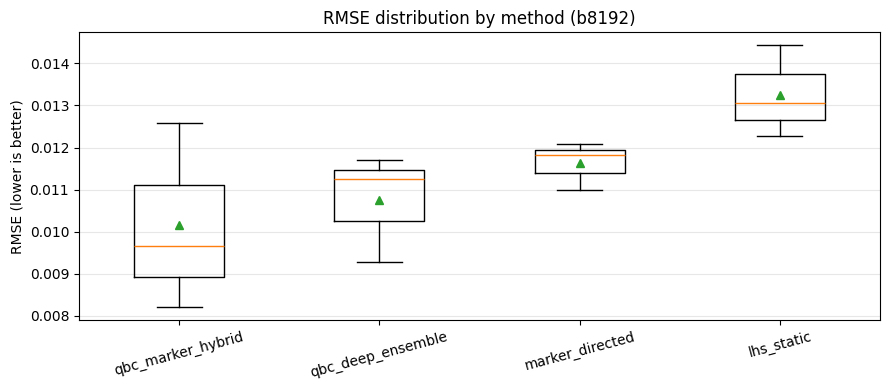

In [23]:
if not df_ok.empty:
    for budget in sorted(df_ok['budget'].unique()):
        d = df_ok[df_ok['budget'] == budget].copy()

        plt.figure(figsize=(9, 4))
        order = (
            d.groupby('method')['rmse']
            .mean()
            .sort_values()
            .index
        )

        data = [d.loc[d['method'] == m, 'rmse'].values for m in order]
        plt.boxplot(data, labels=order, showmeans=True)
        plt.title(f'RMSE distribution by method ({budget})')
        plt.ylabel('RMSE (lower is better)')
        plt.xticks(rotation=15)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

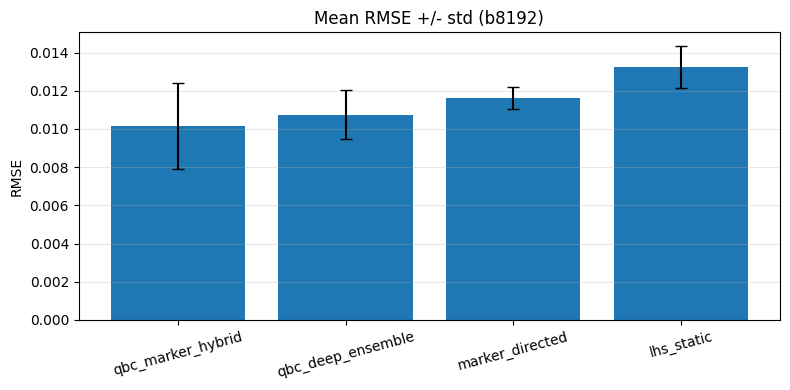

In [24]:
if not df_ok.empty:
    for budget in sorted(df_ok['budget'].unique()):
        d = df_ok[df_ok['budget'] == budget].copy()
        agg = d.groupby('method', as_index=False).agg(rmse_mean=('rmse','mean'), rmse_std=('rmse','std'))
        agg = agg.sort_values('rmse_mean')

        plt.figure(figsize=(8, 4))
        plt.bar(agg['method'], agg['rmse_mean'], yerr=agg['rmse_std'].fillna(0.0), capsize=4)
        plt.title(f'Mean RMSE +/- std ({budget})')
        plt.ylabel('RMSE')
        plt.xticks(rotation=15)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

## Notes

- For final reporting, prefer complete campaigns (all runs have stage-3 completed).
- If campaign rows are marked `skipped_existing`, this notebook still resolves metrics from the corresponding per-run manifests.
- Extend by loading multiple campaign folders and concatenating `df` for cross-run comparisons.